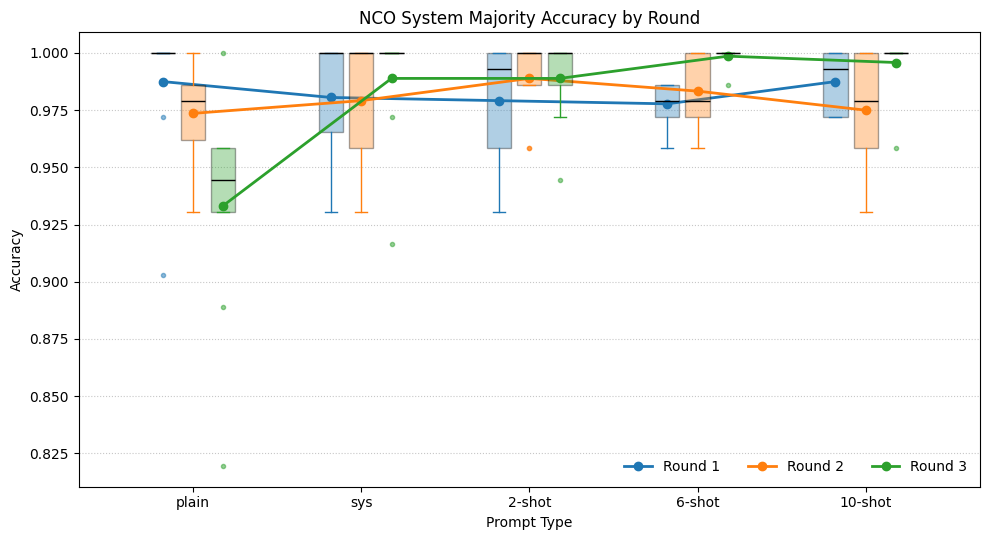

Saved figure to: nco_system_accuracy_boxplot.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# === Load the 3 tieNo files ===
base = Path("./")
files = {
    "Round 1": base / "nco_system_r1_accuracy.csv",
    "Round 2": base / "nco_system_r2_accuracy.csv",
    "Round 3": base / "nco_system_r3_accuracy.csv",
}

# === Prompt label mapping ===
version_to_prompt = {"v1": "plain", "v2": "sys", "v3": "2-shot", "v4": "6-shot", "v5": "10-shot"}
prompt_labels = ["plain", "sys", "2-shot", "6-shot", "10-shot"]

def df_to_series_list(df: pd.DataFrame, prompts):
    """Convert version-based runwise accuracies to list per prompt type."""
    series_by_prompt = []
    for p in prompts:
        v = [k for k, val in version_to_prompt.items() if val == p][0]
        accs = df[df["version"] == v]["accuracy"].dropna().values
        series_by_prompt.append(accs)
    return series_by_prompt

# === Prepare data ===
group_data = []
labels_group = list(files.keys())

for round_name, path in files.items():
    df = pd.read_csv(path)
    group_data.append(df_to_series_list(df, prompt_labels))

# === Color palette ===
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # 蓝、橙、绿

# === Plot ===
x = np.arange(len(prompt_labels))
width = 0.18
offsets = np.linspace(-width, width, len(labels_group))

fig, ax = plt.subplots(figsize=(10, 5.5))

for i, (group, color, offset) in enumerate(zip(group_data, colors, offsets)):
    positions = x + offset
    bp = ax.boxplot(
        group,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.35),
        medianprops=dict(color='black'),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        flierprops=dict(marker='o', markersize=3, alpha=0.5,
                        markerfacecolor=color, markeredgecolor=color),
    )
    means = [np.mean(g) if len(g) else np.nan for g in group]
    ax.plot(positions, means, marker='o', color=color,
            label=labels_group[i], linewidth=2)

# === Axis labels & styling ===
ax.set_xticks(x)
ax.set_xticklabels(prompt_labels)
ax.set_xlabel("Prompt Type")
ax.set_ylabel("Accuracy")
ax.set_title("NCO System Majority Accuracy by Round")

ax.legend(ncol=3, frameon=False)
ax.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()

# === Save ===
out_path = base / "nco_system_accuracy_boxplot.png"
plt.savefig(out_path, dpi=200)
plt.show()

print(f"Saved figure to: {out_path}")


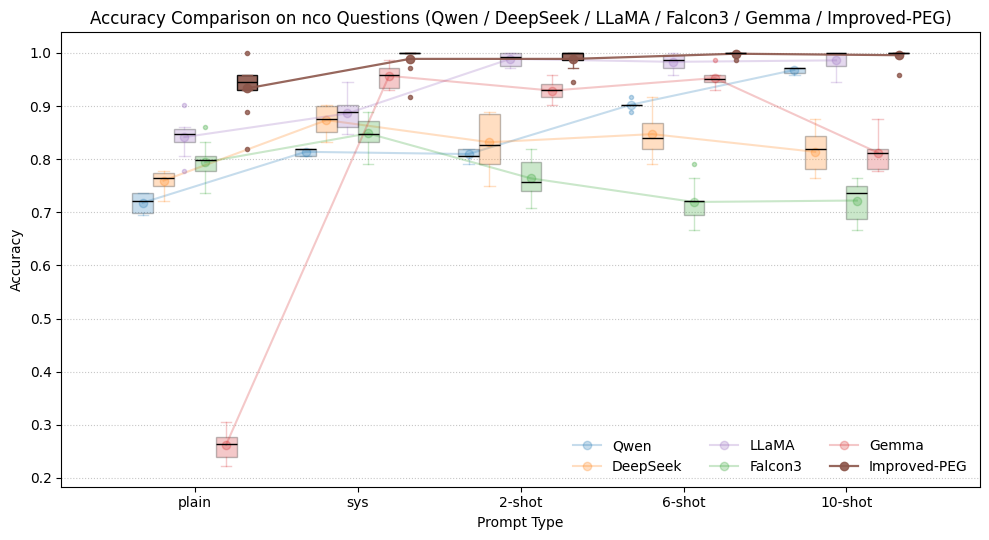

Saved figure to: nco_accuracy_boxplot.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# === Load the 5 nco-accuracy files ===
base = Path("./")
cd = Path("./")
files = {
    "Qwen": base / "nco_qwen_8B_accuracy.csv",
    "DeepSeek": base / "nco_deepseek_8B_accuracy.csv",
    "LLaMA": base / "nco_llama_accuracy.csv",
    "Falcon3": base / "nco_falcon3_7B_accuracy.csv",
    "Gemma": base / "nco_gemma_accuracy.csv",
    "Improved-PEG": cd / "nco_system_r3_accuracy.csv",
}

# === Prompt label mapping ===
version_to_prompt = {"v1": "plain", "v2": "sys", "v3": "2-shot", "v4": "6-shot", "v5": "10-shot"}
prompt_labels = ["plain", "sys", "2-shot", "6-shot", "10-shot"]

def df_to_series_list(df: pd.DataFrame, prompts):
    """Convert version-based runwise accuracies to list per prompt type."""
    series_by_prompt = []
    for p in prompts:
        v = [k for k, val in version_to_prompt.items() if val == p][0]
        accs = df[df["version"] == v]["accuracy"].dropna().values
        series_by_prompt.append(accs)
    return series_by_prompt

# === Prepare data ===
group_data = []
labels_group = list(files.keys())

for model in labels_group:
    df = pd.read_csv(files[model])
    group_data.append(df_to_series_list(df, prompt_labels))

# === Color palette ===
colors = ['#1f77b4', '#ff7f0e', '#9467bd', '#2ca02c', '#d62728', '#8c564b']


# === Plot ===
x = np.arange(len(prompt_labels))
width = 0.16
offsets = np.linspace(-2*width, 2*width, len(labels_group))

fig, ax = plt.subplots(figsize=(10, 5.5))

for i, (group, color, offset) in enumerate(zip(group_data, colors, offsets)):
    positions = x + offset
    alpha = 0.25 if labels_group[i] != "Improved-PEG" else 0.9  # 非 PEG 模型透明
    lw = 1.5 if labels_group[i] != "Improved-PEG" else 1.6      # PEG 线条更粗

    bp = ax.boxplot(
        group,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=alpha),
        medianprops=dict(color='black'),
        whiskerprops=dict(color=color, alpha=alpha),
        capprops=dict(color=color, alpha=alpha),
        flierprops=dict(marker='o', markersize=3, alpha=0.3 if labels_group[i] != "Improved-PEG" else 0.8,
                        markerfacecolor=color, markeredgecolor=color),
    )

    means = [np.mean(g) if len(g) else np.nan for g in group]
    ax.plot(positions, means, marker='o', color=color, linewidth=lw,
            alpha=alpha, label=labels_group[i])

# === Axis labels & styling ===
ax.set_xticks(x)
ax.set_xticklabels(prompt_labels)
ax.set_xlabel("Prompt Type")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Comparison on nco Questions (Qwen / DeepSeek / LLaMA / Falcon3 / Gemma / Improved-PEG)")

ax.legend(ncol=3, frameon=False)
ax.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()

# === Save ===
out_path = cd / "nco_accuracy_boxplot.png"
plt.savefig(out_path, dpi=200)
plt.show()

print(f"Saved figure to: {out_path}")


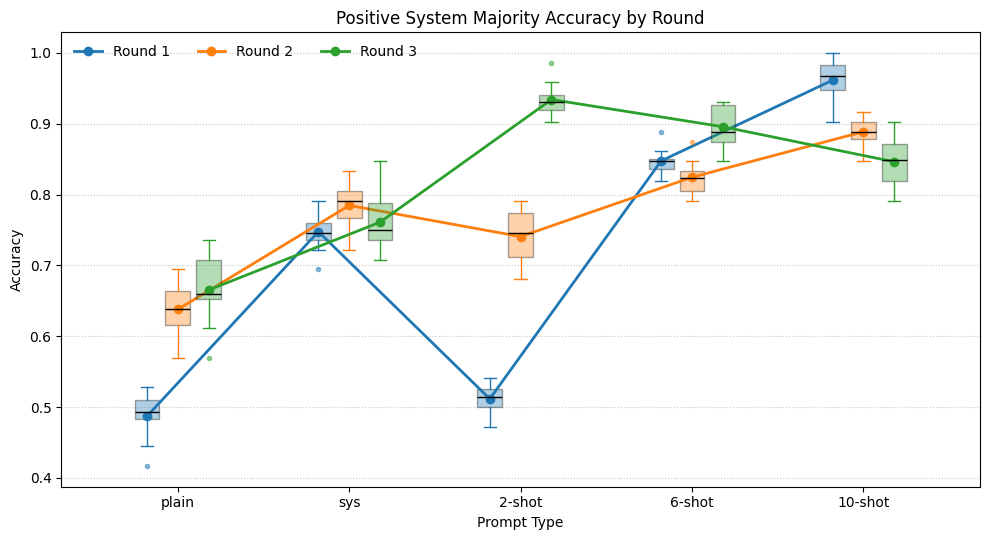

Saved figure to: pos_system_accuracy_boxplot.png


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# === Load the 3 tieNo files ===
base = Path("./")
files = {
    "Round 1": base / "pos_system_r1_accuracy.csv",
    "Round 2": base / "pos_system_r2_accuracy.csv",
    "Round 3": base / "pos_system_r3_accuracy.csv",
}

# === Prompt label mapping ===
version_to_prompt = {"v1": "plain", "v2": "sys", "v3": "2-shot", "v4": "6-shot", "v5": "10-shot"}
prompt_labels = ["plain", "sys", "2-shot", "6-shot", "10-shot"]

def df_to_series_list(df: pd.DataFrame, prompts):
    """Convert version-based runwise accuracies to list per prompt type."""
    series_by_prompt = []
    for p in prompts:
        v = [k for k, val in version_to_prompt.items() if val == p][0]
        accs = df[df["version"] == v]["accuracy"].dropna().values
        series_by_prompt.append(accs)
    return series_by_prompt

# === Prepare data ===
group_data = []
labels_group = list(files.keys())

for round_name, path in files.items():
    df = pd.read_csv(path)
    group_data.append(df_to_series_list(df, prompt_labels))

# === Color palette ===
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # 蓝、橙、绿

# === Plot ===
x = np.arange(len(prompt_labels))
width = 0.18
offsets = np.linspace(-width, width, len(labels_group))

fig, ax = plt.subplots(figsize=(10, 5.5))

for i, (group, color, offset) in enumerate(zip(group_data, colors, offsets)):
    positions = x + offset
    bp = ax.boxplot(
        group,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.35),
        medianprops=dict(color='black'),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        flierprops=dict(marker='o', markersize=3, alpha=0.5,
                        markerfacecolor=color, markeredgecolor=color),
    )
    means = [np.mean(g) if len(g) else np.nan for g in group]
    ax.plot(positions, means, marker='o', color=color,
            label=labels_group[i], linewidth=2)

# === Axis labels & styling ===
ax.set_xticks(x)
ax.set_xticklabels(prompt_labels)
ax.set_xlabel("Prompt Type")
ax.set_ylabel("Accuracy")
ax.set_title("Positive System Majority Accuracy by Round")

ax.legend(ncol=3, frameon=False)
ax.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()

# === Save ===
out_path = base / "pos_system_accuracy_boxplot.png"
plt.savefig(out_path, dpi=200)
plt.show()

print(f"Saved figure to: {out_path}")


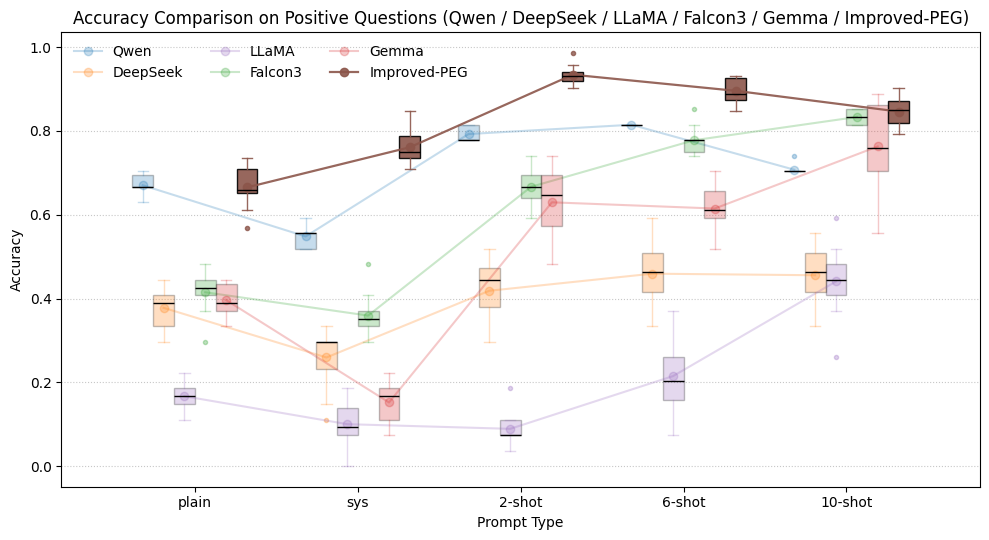

Saved figure to: Positive_accuracy_boxplot.png


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# === Load the 5 nco-accuracy files ===
base = Path("./")
cd = Path("./")
files = {
    "Qwen": base / "positive_qwen_8B_accuracy.csv",
    "DeepSeek": base / "positive_deepseek_8B_accuracy.csv",
    "LLaMA": base / "positive_llama_8B_accuracy.csv",
    "Falcon3": base / "positive_falcon3_7B_accuracy.csv",
    "Gemma": base / "positive_gemma_accuracy.csv",
    "Improved-PEG": cd / "pos_system_r3_accuracy.csv",
}

# === Prompt label mapping ===
version_to_prompt = {"v1": "plain", "v2": "sys", "v3": "2-shot", "v4": "6-shot", "v5": "10-shot"}
prompt_labels = ["plain", "sys", "2-shot", "6-shot", "10-shot"]

def df_to_series_list(df: pd.DataFrame, prompts):
    """Convert version-based runwise accuracies to list per prompt type."""
    series_by_prompt = []
    for p in prompts:
        v = [k for k, val in version_to_prompt.items() if val == p][0]
        accs = df[df["version"] == v]["accuracy"].dropna().values
        series_by_prompt.append(accs)
    return series_by_prompt

# === Prepare data ===
group_data = []
labels_group = list(files.keys())

for model in labels_group:
    df = pd.read_csv(files[model])
    group_data.append(df_to_series_list(df, prompt_labels))

# === Color palette ===
colors = ['#1f77b4', '#ff7f0e', '#9467bd', '#2ca02c', '#d62728', '#8c564b']


# === Plot ===
x = np.arange(len(prompt_labels))
width = 0.16
offsets = np.linspace(-2*width, 2*width, len(labels_group))

fig, ax = plt.subplots(figsize=(10, 5.5))

for i, (group, color, offset) in enumerate(zip(group_data, colors, offsets)):
    positions = x + offset
    alpha = 0.25 if labels_group[i] != "Improved-PEG" else 0.9  # 非 PEG 模型透明
    lw = 1.5 if labels_group[i] != "Improved-PEG" else 1.6      # PEG 线条更粗

    bp = ax.boxplot(
        group,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=alpha),
        medianprops=dict(color='black'),
        whiskerprops=dict(color=color, alpha=alpha),
        capprops=dict(color=color, alpha=alpha),
        flierprops=dict(marker='o', markersize=3, alpha=0.3 if labels_group[i] != "Improved-PEG" else 0.8,
                        markerfacecolor=color, markeredgecolor=color),
    )

    means = [np.mean(g) if len(g) else np.nan for g in group]
    ax.plot(positions, means, marker='o', color=color, linewidth=lw,
            alpha=alpha, label=labels_group[i])

# === Axis labels & styling ===
ax.set_xticks(x)
ax.set_xticklabels(prompt_labels)
ax.set_xlabel("Prompt Type")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Comparison on Positive Questions (Qwen / DeepSeek / LLaMA / Falcon3 / Gemma / Improved-PEG)")

ax.legend(ncol=3, frameon=False)
ax.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()

# === Save ===
out_path = cd / "Positive_accuracy_boxplot.png"
plt.savefig(out_path, dpi=200)
plt.show()

print(f"Saved figure to: {out_path}")
